# [LAB 07] 7. 사후검정
## #01. 준비작업
### 1. 라이브러리 참조

In [1]:
from hossam import load_data
from helpers import *

# 사후 검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_gameshowell

# 시각화 라이브러리
from statannotations.Annotator import Annotator

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기
- tree_weight : 앞 단원에서 ANOVA 분석에서 사용한 소나무 품종별 무게 데이터 셋
    - 등분산성을 충족하는 데이터

In [2]:
origin = load_data('tree_weight')
origin.head()

📚 소나무 품종별 무게를 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,weight,group
0,4.170,A
1,5.580,A
2,5.180,A
3,6.110,A
4,4.500,A


## #02. 사후검정(post hoc)
### 1. 투키의 HSD
- Tuckey's Honestly Significant Difference = "진정으로 유의미한 차이"
- oo(명목형)에 따른 ㅁㅁ(연속형)의 차이라는 의미로 접근
- 데이터가 등분산성을 만족할 경우 수행

In [3]:
tukey_df = pairwise_tukey(data = origin, dv='weight', between='group')
tukey_df

,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,A,B,5.032,4.661,0.371,0.279,1.331,0.391,0.510
1,A,C,5.032,5.526,-0.494,0.279,-1.772,0.198,-0.914
2,B,C,4.661,5.526,-0.865,0.279,-3.103,0.012,-1.289


- 사후분석 결과, b와 c 집단의 평균 차이만 통계적으로 유의하였다(p<0.05)
- 두 집단의 평균은 각각 4.66과 5.53으로 평균차이는 -0.87이었으면 효과크기(hedges)는 -1.29로 큰 수준이었다.
- 즉, c집단의 평균이 b집단보다 유의하게 높았다.
- 반면 a와 b(p>=0.05)와 a와 c(p>=0.05)의 평균 차이는 통계적으로 유의하지 않았다.

### 2. Games-Howell 검정
- Games-Howell 검정은 다수의 그룹 간의 평균 차이를 비교하는 통계적 방법 중 하나로, 등분산성 가정이 만족되지 않을 때 사용한다.

In [4]:
gh_df = pairwise_gameshowell(origin, dv='weight', between='group')
gh_df

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,A,B,5.032,4.661,0.371,0.311,1.191,16.524,0.475,0.510
1,A,C,5.032,5.526,-0.494,0.231,-2.134,16.786,0.113,-0.914
2,B,C,4.661,5.526,-0.865,0.287,-3.010,14.104,0.024,-1.289


## #03. 사후검정 결과 시각화
### 1. 그룹 순서 추출

In [5]:
order = sorted(origin['group'].unique())
order

['A', 'B', 'C']

### 2. 비교 대상 그룹 쌍 추출
- A열과 B열을 짝지어 (그룹1, 그룹2) 형태로 묶는다.

In [6]:
pairs = list(zip(tukey_df['A'], tukey_df['B']))
pairs

[('A', 'B'), ('A', 'C'), ('B', 'C')]

### 3. 각 그룹에 대응하는 p값 추출

In [7]:
pvalues = list(tukey_df['p_tukey'])
pvalues

[0.39087114420210534, 0.1979959912995718, 0.012006423979493142]

### 4. 시각화 구현

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

A vs. B: Custom statistical test, P_val:3.909e-01
B vs. C: Custom statistical test, P_val:1.201e-02
A vs. C: Custom statistical test, P_val:1.980e-01


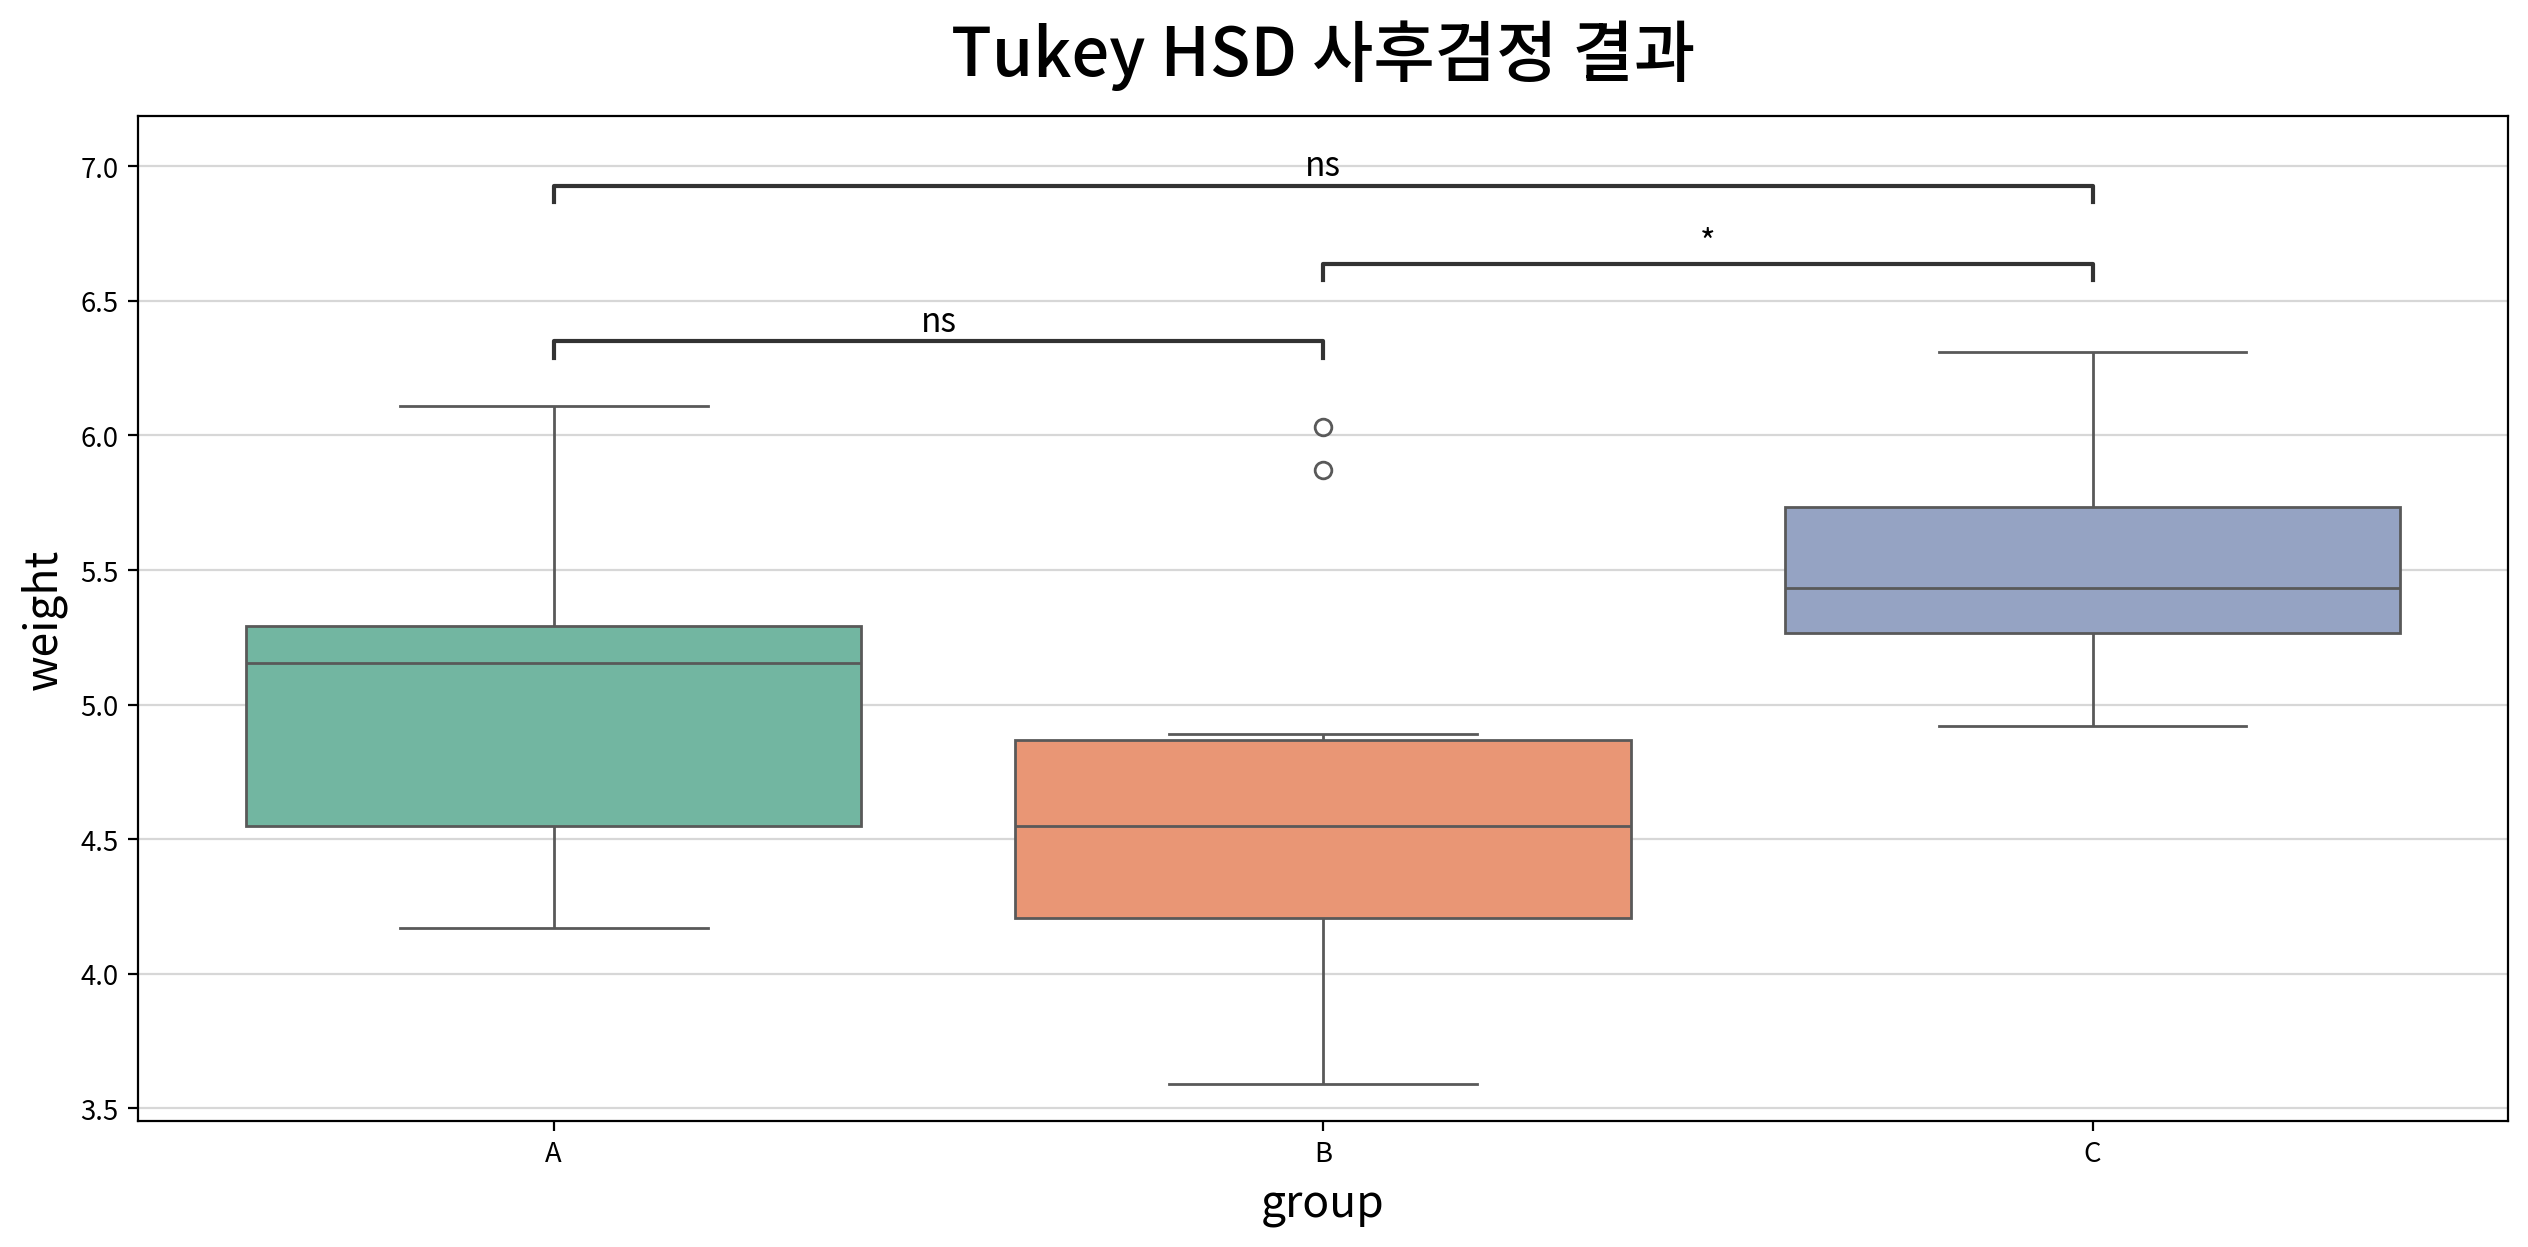

In [9]:
# 그래프 초기화
fig, ax = my_plot.init(title='Tukey HSD 사후검정 결과', xlabel='group', ylabel='weight')

# my_plot.boxplot으로 그룹별 분포 시각화
my_plot.boxplot(data=origin, x='group', y='weight', hue='group', palette='Set2', order=order, ax=ax)

# Annotator로 그룹 간 유의성(p-value) 주석을 박스플롯 위에 추가
annotator = Annotator(ax, pairs, data=origin, x='group', y='weight', order=order)

# Tukey 검정에서 구한 p값을 그대로 주입
annotator.set_pvalues(pvalues)
annotator.annotate()

# my_plot.show로 그래프 출력
my_plot.show()

## #04. 모듈화 기능 확인
### 1. 사후검정 및 결과 시각화 일괄 처리

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

A vs. B: Custom statistical test, P_val:3.909e-01
B vs. C: Custom statistical test, P_val:1.201e-02
A vs. C: Custom statistical test, P_val:1.980e-01


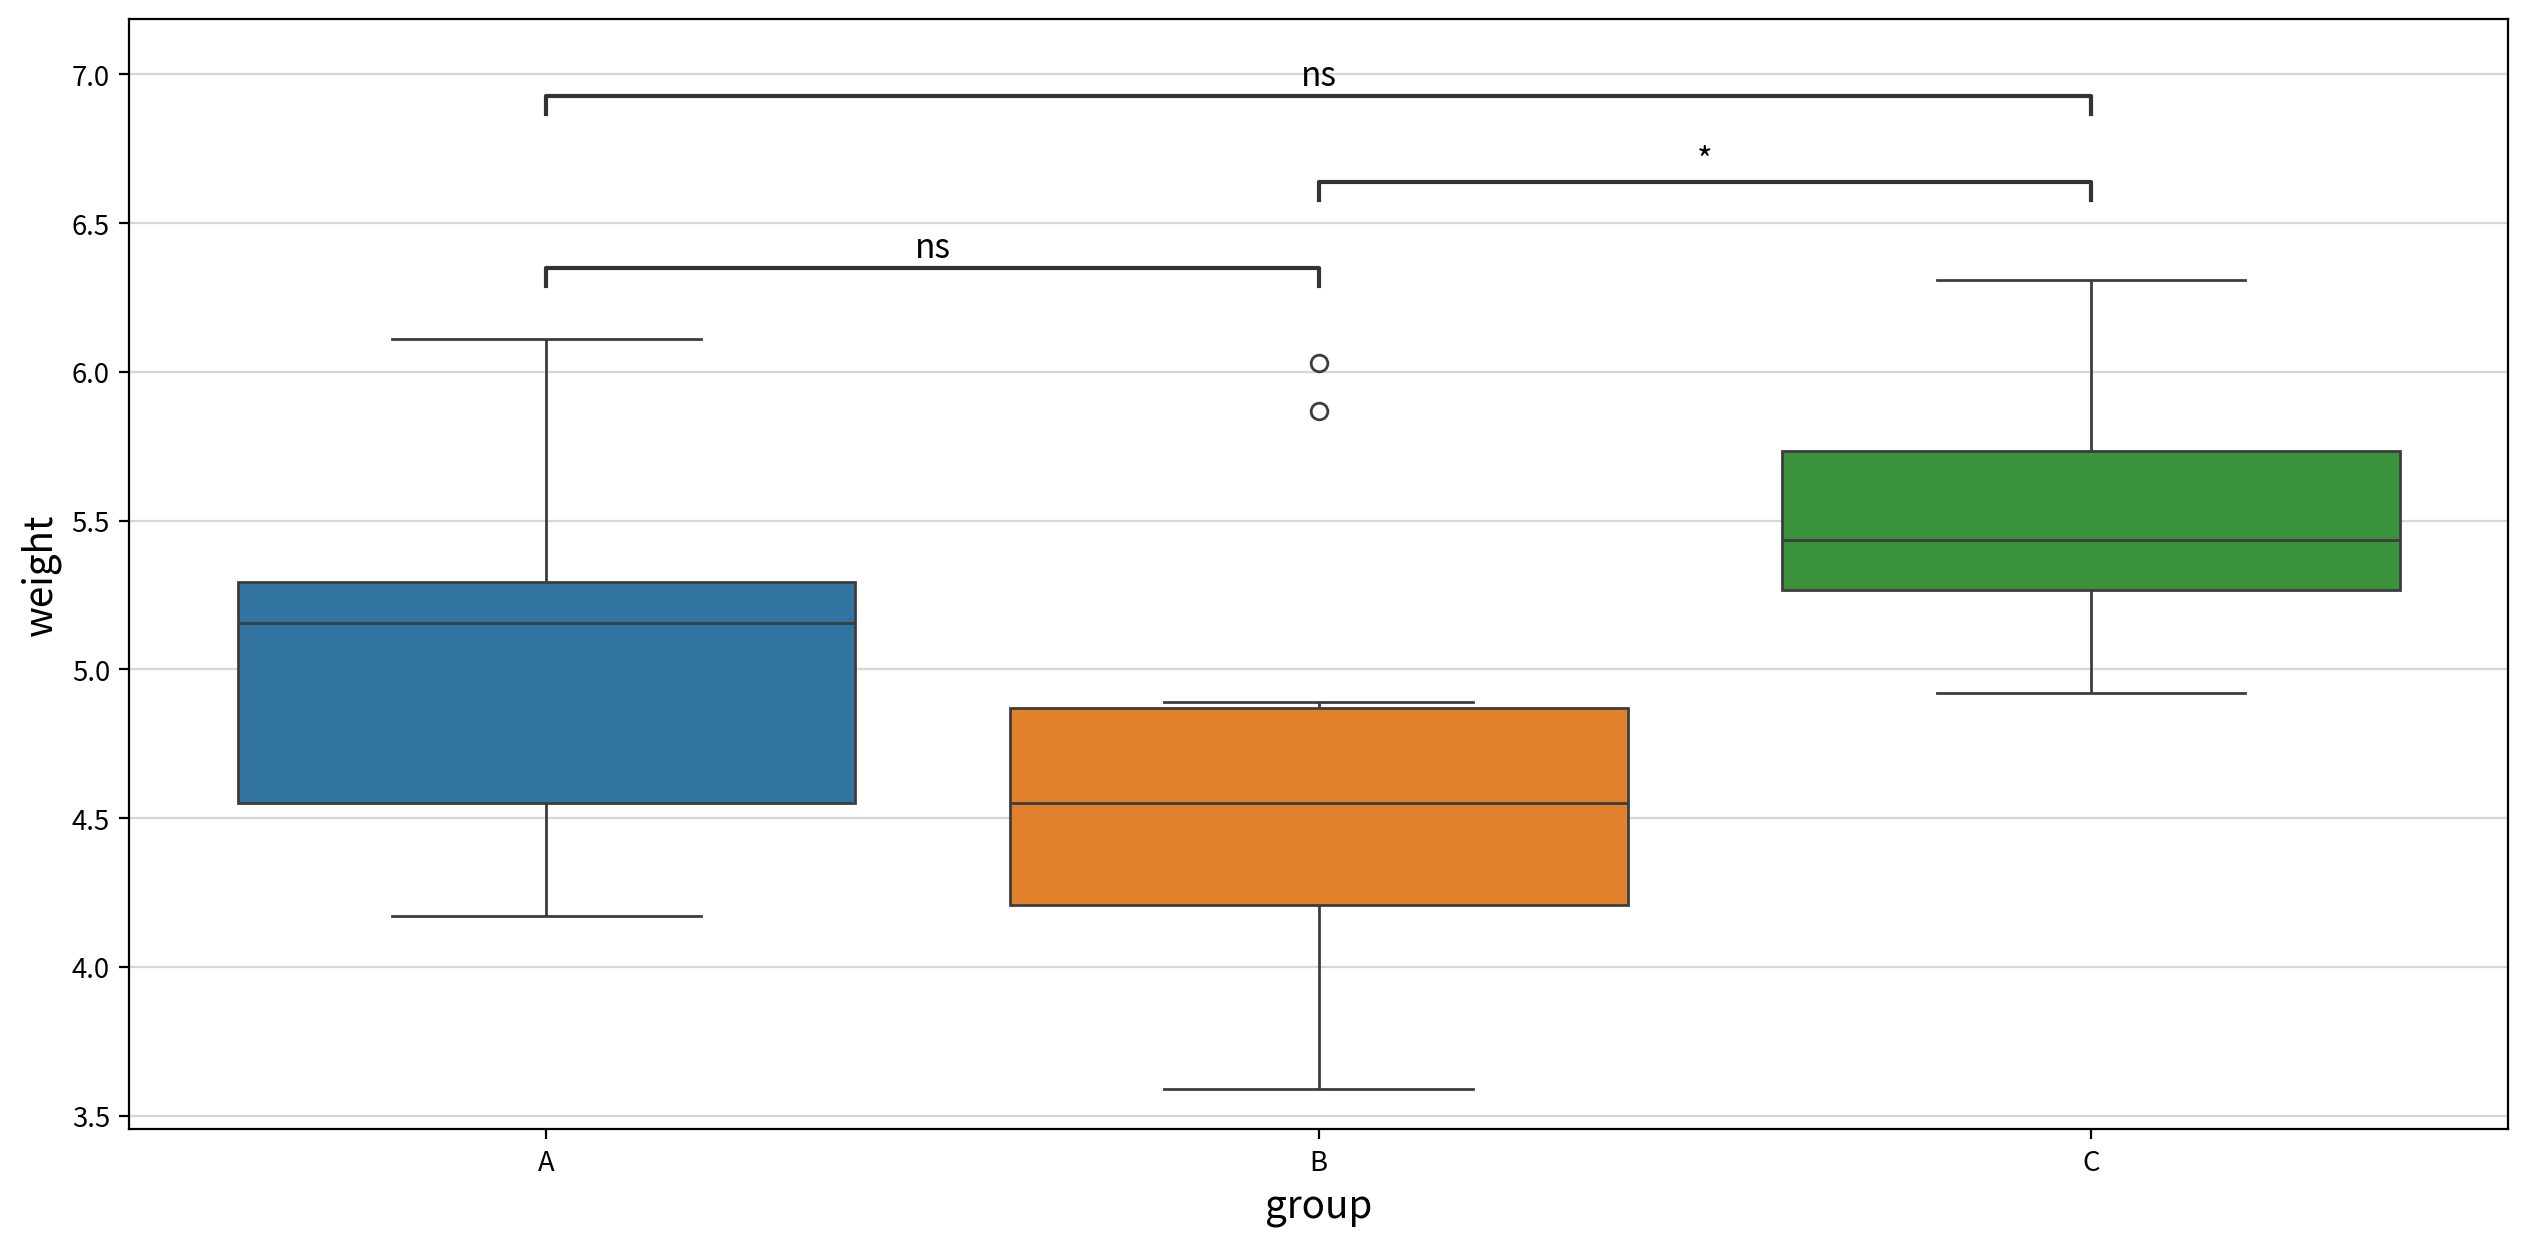

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,A,B,5.032,4.661,0.371,0.279,1.331,0.391,0.510,False,Medium
1,Tukey HSD,A,C,5.032,5.526,-0.494,0.279,-1.772,0.198,-0.914,False,Large
2,Tukey HSD,B,C,4.661,5.526,-0.865,0.279,-3.103,0.012,-1.289,True,Large


In [ ]:
my_stats.posthoc_oneway(origin, y='weight', between='group')